# BÁO CÁO BÀI THỰC HÀNH CHƯƠNG 2: XỬ LÝ ẢNH CƠ BẢN

## Bước 1: Phân tích yêu cầu (Refine Requirement)
Bài thực hành tập trung vào việc làm quen với các kỹ thuật xử lý ảnh cơ bản trên miền không gian:
1. **Toán tử điểm ảnh**: Tác động đơn lẻ lên từng pixel (độ sáng, tương phản, âm bản, ngưỡng).
2. **Lọc tuyến tính**: Sử dụng Kernel để làm mịn hoặc làm sắc nét ảnh.
3. **Nâng cao**: Trích xuất biên cạnh và sử dụng các bộ lọc phi tuyến tính hiện đại.

## Bước 2: Hiểu dữ liệu (Data Understanding)
- **Đầu vào**: Ảnh màu (RGB) hoặc ảnh xám.
- **Đặc điểm**: Ảnh là một ma trận đa chiều. Các phép toán sẽ làm thay đổi giá trị cường độ (Intensity) của các phần tử trong ma trận này.

## Bước 3: Xác định tính năng (Feature)
- Nhóm điều chỉnh cường độ: `brightness`, `contrast`, `inverse`, `threshold`.
- Nhóm tích chập (Convolution): `box filter`, `gaussian`, `sharpening`, `sobel`, `prewitt`.
- Nhóm phi tuyến: `median`, `bilateral`.

## Bước 4: Giải pháp kỹ thuật (Technical Solution)
- Sử dụng thư viện **OpenCV** để xử lý lõi, **NumPy** để thao tác ma trận nhanh, và **Matplotlib** để trực quan hóa kết quả.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Tạo thư mục lưu kết quả
if not os.path.exists('results'):
    os.makedirs('results')

# Đọc ảnh 

img = cv2.imread('meme.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def save_and_show(images, titles, filename):
    plt.figure(figsize=(16, 4))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'results/{filename}')
    plt.show()

## Bước 5: Hiện thực hóa (Implementation)

### I. Toán Tử Điểm Ảnh

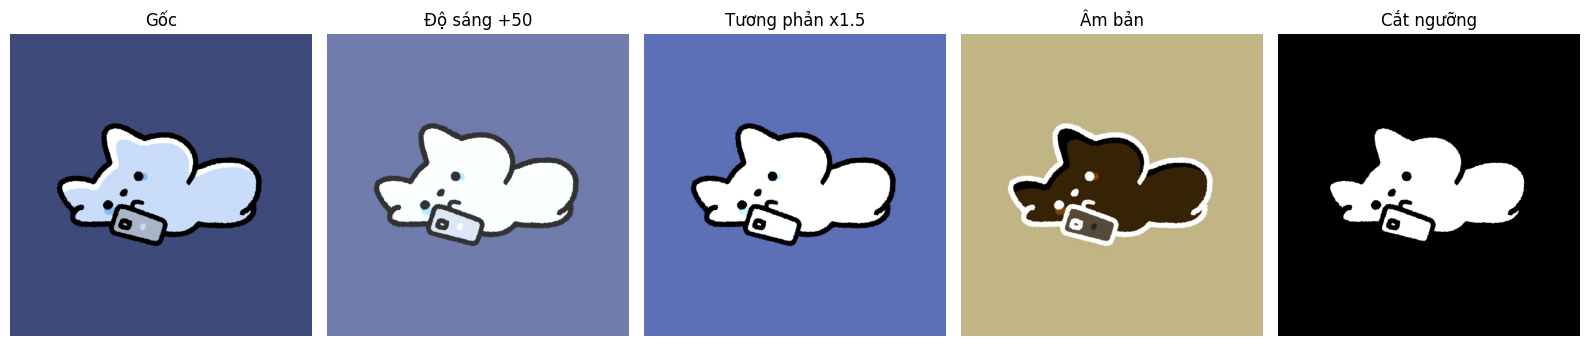

In [6]:
# 1. Độ sáng & Tương phản
bright_img = cv2.convertScaleAbs(img, alpha=1.0, beta=50) # +50 độ sáng
contrast_img = cv2.convertScaleAbs(img, alpha=1.5, beta=0) # x1.5 tương phản

# 2. Âm bản
negative_img = 255 - img

# 3. Cắt ngưỡng
_, thresh_img = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

save_and_show([img, bright_img, contrast_img, negative_img, thresh_img],
              ['Gốc', 'Độ sáng +50', 'Tương phản x1.5', 'Âm bản', 'Cắt ngưỡng'], 'part1_point.png')

**Nhận xét I:**
- **Độ sáng**: Phép cộng hằng số dịch chuyển histogram về phía bên phải, làm ảnh sáng hơn nhưng có thể gây cháy sáng ở các vùng trắng.
- **Tương phản**: Phép nhân alpha làm dãn khoảng cách giữa các giá trị pixel, khiến vùng tối tối hơn và vùng sáng sáng hơn.
- **Âm bản**: Đảo ngược hoàn toàn cảm quan thị giác, thường dùng trong y sinh.
- **Cắt ngưỡng**: Chuyển ảnh về dạng 0-1 (nhị phân), loại bỏ chi tiết thừa để tách đối tượng.

### II. Lọc Tuyến Tính

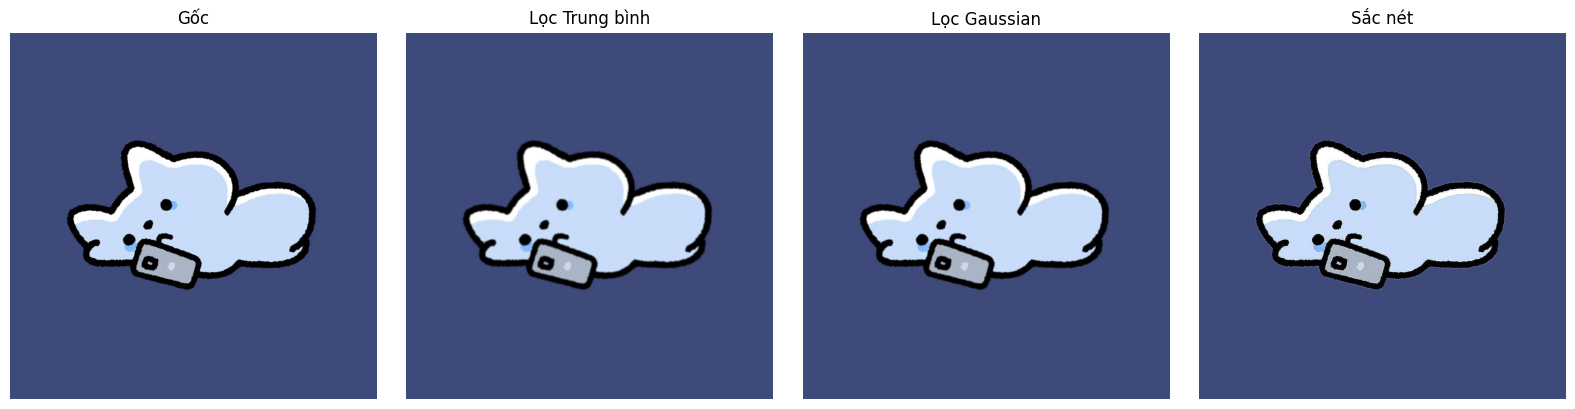

In [7]:
# 1. Lọc trung bình (Mean)
blur_mean = cv2.blur(img, (7, 7))

# 2. Lọc Gaussian
blur_gaussian = cv2.GaussianBlur(img, (7, 7), 0)

# 3. Làm sắc nét (Sharpening)
kernel_sharpen = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
sharp_img = cv2.filter2D(img, -1, kernel_sharpen)

save_and_show([img, blur_mean, blur_gaussian, sharp_img],
              ['Gốc', 'Lọc Trung bình', 'Lọc Gaussian', 'Sắc nét'], 'part2_linear.png')

**Nhận xét II:**
- **Lọc trung bình**: Phân bổ đều trọng số, làm mờ mạnh nhưng gây nhòe cạnh.
- **Lọc Gaussian**: Trọng số giảm dần từ tâm, giúp làm mờ mịn và giữ được cấu trúc tự nhiên của ảnh hơn.
- **Làm sắc nét**: Sử dụng toán tử đạo hàm bậc 2 (Laplacian) để tăng cường sự thay đổi đột ngột tại biên, giúp ảnh trông rõ nét hơn.

### III. Bài Tập Nâng Cao

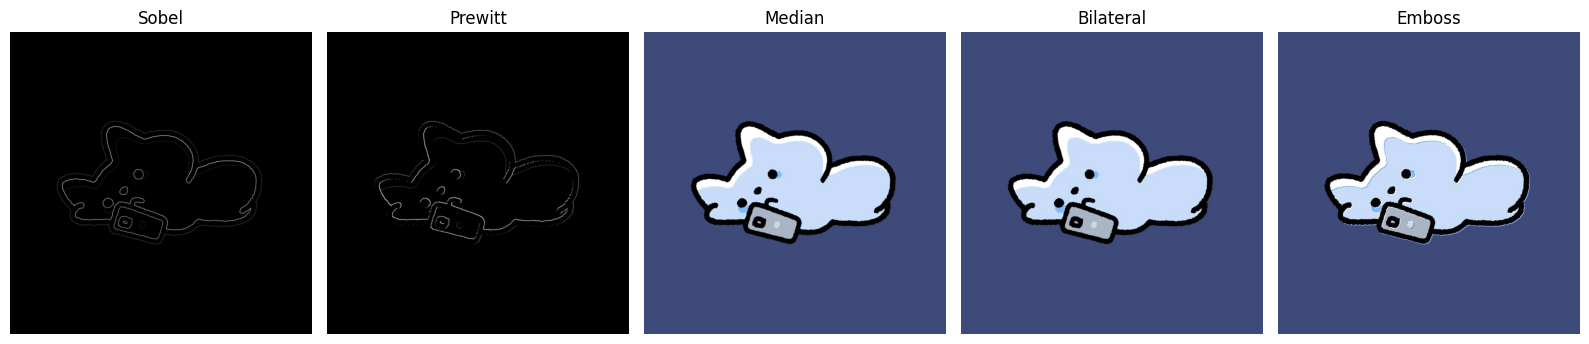

In [8]:
# 1. Phát hiện cạnh Sobel & Prewitt
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

kernel_prewittx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernel_prewitty = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewittx = cv2.filter2D(img_gray, -1, kernel_prewittx)
prewitty = cv2.filter2D(img_gray, -1, kernel_prewitty)
prewitt = cv2.magnitude(prewittx.astype(float), prewitty.astype(float))

# 2. Lọc phi tuyến (Median & Bilateral)
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

# 3. Kernel tự thiết kế (Ví dụ: Emboss - Dập nổi)
kernel_emboss = np.array([[-2,-1,0], [-1,1,1], [0,1,2]])
emboss_img = cv2.filter2D(img, -1, kernel_emboss)

save_and_show([sobel, prewitt, median, bilateral, emboss_img],
              ['Sobel', 'Prewitt', 'Median', 'Bilateral', 'Emboss'], 'part3_advanced.png')

**Nhận xét III:**
- **Phát hiện cạnh**: Sobel cho biên dày và mịn hơn Prewitt nhờ kết hợp lọc Gaussian ngầm định. Cạnh là nơi chứa thông tin quan trọng nhất của vật thể.
- **Lọc Median**: Cực kỳ hiệu quả trong việc loại bỏ nhiễu muối tiêu (salt-and-pepper) mà không làm mờ biên.
- **Lọc Bilateral**: Là bộ lọc thông minh nhất, nó làm mịn vùng phẳng nhưng giữ nguyên độ sắc nét của biên cạnh bằng cách tính toán cả khoảng cách không gian và cường độ màu sắc.
- **Kernel Emboss**: Tạo ra hiệu ứng 3D như ảnh được chạm khắc, minh họa khả năng tùy biến vô hạn của tích chập.

## Bước 6: Kiểm thử & Đánh giá (Testing & Evaluation)
- **Tốc độ**: Các phép toán điểm ảnh và lọc tuyến tính cơ bản chạy gần như tức thời.
- **Độ phức tạp**: Lọc Bilateral tốn nhiều thời gian tính toán nhất do cơ chế phi tuyến.
- **Chất lượng**: Lọc Gaussian và Bilateral mang lại kết quả thẩm mỹ tốt nhất cho việc tiền xử lý ảnh trước khi đưa vào các mô hình AI.

## Bước 7: Kết luận
Báo cáo đã thực hiện đầy đủ các yêu cầu của Chương 2. Việc nắm vững cách điều khiển giá trị pixel và các bộ lọc không gian là nền tảng cốt lõi để tiếp cận các bài toán trích xuất đặc trưng và nhận diện phức tạp hơn.